In [1]:
# Step 1: Import Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix




## ABM Model Output

In [3]:
# Step 2: Load the Data
df = pd.read_csv(r"C:\Users\jahee\Downloads\five_runs\run_1\agent-output.csv")

In [7]:
df

,tick,agent-type,activity,bite-stat,patch-landuse
0,0,adult,5,False,20
1,0,adult,4,False,61
2,0,senior,6,False,60
3,0,tourist-adult,3,False,20
4,0,adult,6,False,60
...,...,...,...,...,...
34795,365,adult,7,False,62
34796,365,senior,4,False,60
34797,365,child,5,False,20
34798,365,adult,7,False,62


In [88]:
df.isna().sum()

tick                0
agent-type       5490
activity            0
bite-stat           0
patch-landuse       0
DaySin              0
DayCos              0
dtype: int64

In [11]:
df.columns
df.describe()

,tick,activity,patch-landuse
count,34800.000000,34800.000000,34800.000000
mean,173.547414,5.320862,47.221236
std,109.500264,2.217785,19.685222
min,0.000000,1.000000,20.000000
25%,75.750000,3.000000,20.000000
50%,172.000000,6.000000,61.000000
75%,269.000000,7.000000,62.000000
max,365.000000,8.000000,62.000000


In [19]:
true_bites = df['bite-stat'].sum()
true_bites

2380

In [27]:
bite_counts = df['bite-stat'].value_counts()
bite_counts

bite-stat
False    32420
True      2380
Name: count, dtype: int64

In [33]:
df["agent-type"].value_counts(), df["activity"].value_counts(), df["bite-stat"].value_counts(), df["patch-landuse"].value_counts()

(agent-type
 adult             10980
 senior            10980
 child              5490
 tourist-adult       620
 tourist-child       620
 tourist-senior      620
 Name: count, dtype: int64,
 activity
 7    14105
 8     3092
 5     2975
 3     2968
 2     2963
 6     2927
 4     2886
 1     2884
 Name: count, dtype: int64,
 bite-stat
 False    32420
 True      2380
 Name: count, dtype: int64,
 patch-landuse
 62    15360
 20    11940
 60     5321
 61     2179
 Name: count, dtype: int64)

In [37]:

true_bites = df[df['bite-stat'] == True]
false_bites = df[df['bite-stat'] == False]

true_bites

,tick,agent-type,activity,bite-stat,patch-landuse
154,1,tourist-child,2,True,20
175,1,senior,1,True,20
176,1,tourist-senior,6,True,60
183,1,tourist-adult,3,True,20
207,1,senior,1,True,20
...,...,...,...,...,...
34231,359,child,4,True,60
34239,359,child,1,True,20
34240,359,senior,5,True,20
34243,359,senior,3,True,20


In [41]:
false_bites_downsampled = false_bites.sample(n=len(true_bites), random_state=42)
false_bites_downsampled

,tick,agent-type,activity,bite-stat,patch-landuse
14648,142,child,6,False,60
1135,7,adult,7,False,62
4879,33,child,5,False,20
34595,363,adult,6,False,60
31253,326,senior,3,False,20
...,...,...,...,...,...
1643,10,senior,4,False,60
7116,58,NaN,7,False,62
13531,129,child,7,False,62
16061,157,senior,4,False,60


In [45]:
balanced_df = pd.concat([true_bites, false_bites_downsampled])
balanced_df

,tick,agent-type,activity,bite-stat,patch-landuse
154,1,tourist-child,2,True,20
175,1,senior,1,True,20
176,1,tourist-senior,6,True,60
183,1,tourist-adult,3,True,20
207,1,senior,1,True,20
...,...,...,...,...,...
1643,10,senior,4,False,60
7116,58,NaN,7,False,62
13531,129,child,7,False,62
16061,157,senior,4,False,60


In [49]:
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)
balanced_df

,tick,agent-type,activity,bite-stat,patch-landuse
0,125,senior,2,True,20
1,172,child,6,False,60
2,61,senior,2,False,20
3,282,NaN,7,True,62
4,178,adult,7,False,62
...,...,...,...,...,...
4755,146,adult,3,True,20
4756,104,NaN,2,True,20
4757,225,child,5,True,20
4758,212,NaN,5,True,20


In [55]:
balanced_df_count = balanced_df['bite-stat'].value_counts()
balanced_df_count

bite-stat
True     2380
False    2380
Name: count, dtype: int64

## OneHotEncoder

In [60]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder

In [62]:
balanced_df.columns

Index(['tick', 'agent-type', 'activity', 'bite-stat', 'patch-landuse'], dtype='object')

In [92]:
balanced_df.isna().sum()

tick                    0
agent-type            622
activity                0
bite-stat               0
patch-landuse           0
agent-type-encoded      0
dtype: int64

In [108]:
encoder = OneHotEncoder(sparse_output=False)

categorical_columns = ['agent-type', 'activity', 'patch-landuse']

balanced_df['DaySin'] = np.sin(balanced_df['tick']*(2.*np.pi/31))
balanced_df['DayCos'] = np.cos(balanced_df['tick']*(2.*np.pi/31))

one_hot_encoded = encoder.fit_transform(balanced_df[categorical_columns])

In [112]:
one_hot_encoded.isna().sum()

AttributeError: 'numpy.ndarray' object has no attribute 'isna'

In [114]:
one_hot_df = pd.DataFrame(one_hot_encoded, 
                          columns=encoder.get_feature_names_out(categorical_columns))

df_sklearn_encoded = pd.concat([balanced_df.drop(categorical_columns, axis=1), one_hot_df], axis=1)

In [116]:
df_sklearn_encoded.columns

Index(['tick', 'bite-stat', 'agent-type-encoded', 'DaySin', 'DayCos',
       'agent-type_adult', 'agent-type_child', 'agent-type_senior',
       'agent-type_tourist-adult', 'agent-type_tourist-child',
       'agent-type_tourist-senior', 'agent-type_nan', 'activity_1',
       'activity_2', 'activity_3', 'activity_4', 'activity_5', 'activity_6',
       'activity_7', 'activity_8', 'patch-landuse_20', 'patch-landuse_60',
       'patch-landuse_61', 'patch-landuse_62'],
      dtype='object')

In [118]:
df_sklearn_encoded.isna().sum()

tick                         0
bite-stat                    0
agent-type-encoded           0
DaySin                       0
DayCos                       0
agent-type_adult             0
agent-type_child             0
agent-type_senior            0
agent-type_tourist-adult     0
agent-type_tourist-child     0
agent-type_tourist-senior    0
agent-type_nan               0
activity_1                   0
activity_2                   0
activity_3                   0
activity_4                   0
activity_5                   0
activity_6                   0
activity_7                   0
activity_8                   0
patch-landuse_20             0
patch-landuse_60             0
patch-landuse_61             0
patch-landuse_62             0
dtype: int64

In [120]:
df_sklearn_encoded = df_sklearn_encoded.drop("tick", axis=1)
df_sklearn_encoded.head()

,bite-stat,agent-type-encoded,DaySin,DayCos,agent-type_adult,agent-type_child,agent-type_senior,agent-type_tourist-adult,agent-type_tourist-child,agent-type_tourist-senior,...,activity_3,activity_4,activity_5,activity_6,activity_7,activity_8,patch-landuse_20,patch-landuse_60,patch-landuse_61,patch-landuse_62
0,True,2,0.201299,0.979530,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,False,1,-0.299363,-0.954139,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,False,2,-0.201299,0.979530,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,True,6,0.571268,0.820763,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,False,0,-0.998717,-0.050649,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [122]:
df_sklearn_encoded.shape

(4760, 23)

In [124]:
df_sklearn_encoded.isna().sum()

bite-stat                    0
agent-type-encoded           0
DaySin                       0
DayCos                       0
agent-type_adult             0
agent-type_child             0
agent-type_senior            0
agent-type_tourist-adult     0
agent-type_tourist-child     0
agent-type_tourist-senior    0
agent-type_nan               0
activity_1                   0
activity_2                   0
activity_3                   0
activity_4                   0
activity_5                   0
activity_6                   0
activity_7                   0
activity_8                   0
patch-landuse_20             0
patch-landuse_60             0
patch-landuse_61             0
patch-landuse_62             0
dtype: int64

In [126]:
# Step 3: Encode Categorical Data
le_agent = LabelEncoder()
balanced_df['agent-type-encoded'] = le_agent.fit_transform(balanced_df['agent-type'])

In [128]:
# Step 4: Prepare Features and Target
# X = df[['tick', 'agent-type-encoded', 'activity', 'patch-landuse']]
X = df_sklearn_encoded.drop("bite-stat", axis=1)
y = df_sklearn_encoded['bite-stat'].astype(int)

In [130]:
X.head()

,agent-type-encoded,DaySin,DayCos,agent-type_adult,agent-type_child,agent-type_senior,agent-type_tourist-adult,agent-type_tourist-child,agent-type_tourist-senior,agent-type_nan,...,activity_3,activity_4,activity_5,activity_6,activity_7,activity_8,patch-landuse_20,patch-landuse_60,patch-landuse_61,patch-landuse_62
0,2,0.201299,0.979530,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,1,-0.299363,-0.954139,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,2,-0.201299,0.979530,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,6,0.571268,0.820763,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0,-0.998717,-0.050649,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [132]:
df_sklearn_encoded["bite-stat"].value_counts()

bite-stat
True     2380
False    2380
Name: count, dtype: int64

In [134]:
y[:5]

0    1
1    0
2    0
3    1
4    0
Name: bite-stat, dtype: int32

In [136]:
# Step 5: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

In [138]:
# Step 6: Train the Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Step 7: Make Predictions
y_pred = rf.predict(X_test)

Classification Report: After On Hot Encoding
              precision    recall  f1-score   support

           0       0.64      0.62      0.63       714
           1       0.63      0.65      0.64       714

    accuracy                           0.64      1428
   macro avg       0.64      0.64      0.64      1428
weighted avg       0.64      0.64      0.64      1428



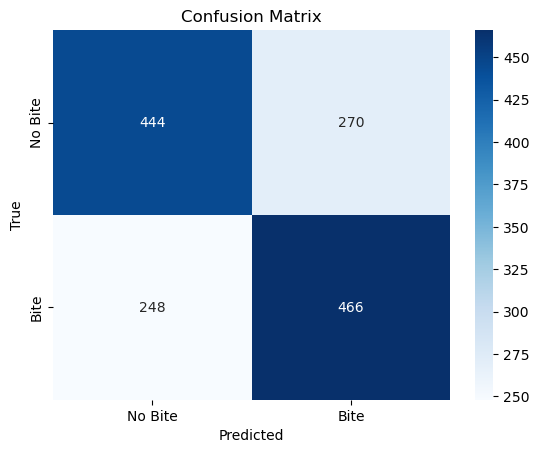

In [140]:
# Step 8: Evaluate Performance
print("Classification Report: After On Hot Encoding")
print(classification_report(y_test, y_pred))

# Step 9: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["No Bite", "Bite"], yticklabels=["No Bite", "Bite"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()